# Optimization in python: k - dominating set

In the following notebook, we will detail, implement, and test a sequence of algorithms for defining a reachability graph, and finding and minimizing a k - dominating in said graph.

In [16]:
import networkx as nx
import osmnx as ox
import sys
from pathlib import Path
import scipy as sp
import random
import numpy as np
from typing import Set

Consider the road graph of Tel Aviv:

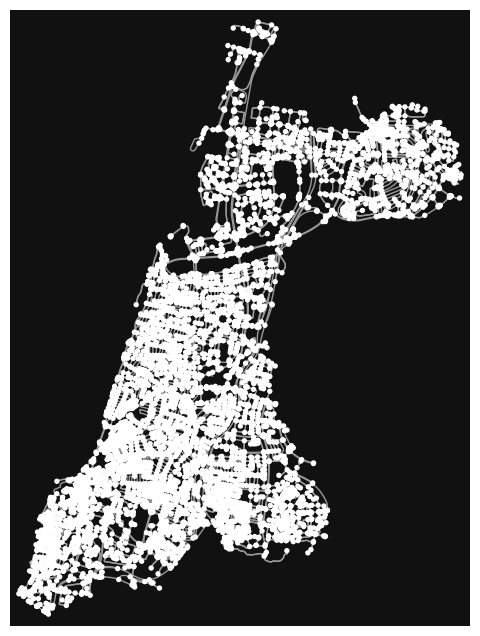

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [4]:
G = ox.graph_from_place("Tel Aviv, Israel", network_type="drive")
ox.plot_graph(G)

In [26]:
# Compute the average length of an edge:
edge_lengths = [data['length'] for u, v, data in G.edges(data=True)]

# Compute mean
mean_length = np.mean(edge_lengths)

print(f"Mean edge length: {mean_length:.2f} meters")

Mean edge length: 83.73 meters


## Reachability graph definition
In the article on page 4, we define a reachability graph, given a specified real-valued t.




In [27]:
shortest_paths = dict(nx.all_pairs_dijkstra_path_length(G, weight='length'))


In [ ]:
all_distances = [dist for paths in shortest_paths.values() for dist in paths.values() if dist > 0]

# Compute average - helpful for choosing "t" values for the reachability graphs, later
avg = sum(all_distances) / len(all_distances)

In [ ]:
def setup_reachability_graph(G, shortest_path_dict, t=2.0):
    distances = shortest_path_dict
    reachability_graph = nx.Graph()
    reachability_graph.add_nodes_from(G.nodes())
    
    nodes = list(G.nodes())
    for i, u in enumerate(nodes):
        for j, v in enumerate(nodes):
            if i < j:
                try:
                    if distances[u][v] <= t:
                        reachability_graph.add_edge(u, v)
                except KeyError:
                    pass
    # return nx.to_scipy_sparse_matrix(reachability_graph, format = 'coo')
    return nx.to_scipy_sparse_array(reachability_graph, format='csr') #Good for "squeezing" a row to only it's 1 indices


## Finding a k-dominating set
We utilize Algorithm 1 (page 11) from the paper (eschewing the unexplained definition of p, and assuming p is a given) to randomly choose a set, and then complete it to be k - dominating.

In [ ]:


def randomized_k_dominating_set(matrix, k: int, seed: int = None) -> Set[int]:
    # use seed if reproducibility is desired in debugging/testing
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    n = matrix.shape[0]
    max_degree = get_max_degree(matrix)
    if k > max_degree or n == 0 or k == 0:
        return set()
    p = .1
    A = set()
    for v in range(n):
        if random.random() < p:
            A.add(v)
    B = set()
    for v in range(n):
        if v not in A:
            neighbors_v = get_neighbors(matrix, v)
            neighbors_in_A = neighbors_v.intersection(A)
            if len(neighbors_in_A) < k:
                B.add(v)
    D = A.union(B)
    return D


def get_max_degree(matrix) -> int:
    degrees = np.diff(matrix.indptr)
    return int(np.max(degrees)) if len(degrees) > 0 else 0


def get_neighbors(matrix, vertex: int) -> Set[int]:
    start = matrix.indptr[vertex]
    end = matrix.indptr[vertex + 1]
    neighbors = matrix.indices[start:end]
    return set(neighbors)


## Minimizing the set
Next, we utilize algorithm 3 (Page 12) to greedily remove vertices from the graph while maintaining the domination.

In [ ]:

def minimize_k_dominating_set(matrix, dominating_set, k): #Assumes "matrix" is a scipy.sparse CSR matrix
    ordered_set = order_set_by_neighbours(matrix, dominating_set) #this is a list, ordered in increasing order of num. of neighbours
    for node in ordered_set:
        dominating_set.remove(node)
        if not is_dominating_set(matrix, dominating_set, k):
            dominating_set.add(node) #Add the node back
    return dominating_set

def order_set_by_neighbours(matrix, dominating_set):
    ls = [(node, num_of_neighbours(node, matrix, dominating_set)) for node in dominating_set]
    ls_sorted = sorted(ls, key=lambda x: x[1])
    return [x[0] for x in ls_sorted]

def num_of_neighbours(node, matrix, dominating_set):
    start = matrix.indptr[node]
    end = matrix.indptr[node+1] # look only at row "node" of the matrix
    neighbors = matrix.indices[start:end] #all "1" indices
    return sum(1 for neighbor in neighbors if neighbor != node and neighbor not in dominating_set)

def is_dominating_set(matrix, checked_set, k):
    for node in range(matrix.shape[0]):
        start = matrix.indptr[node]
        end = matrix.indptr[node+1]
        neighbors = matrix.indices[start:end]
        if not ( node in checked_set or sum(1 for neighbor in neighbors if neighbor in checked_set) >= k):
            return False # there is a node that is not dominated
    return True




Now that all our algorithms are defined, we may examine some properties of the graph itself...

In [10]:
print(avg)
print(G.number_of_nodes())
print(G.number_of_edges())

5748.607700025021
6477
12435


...A very sparse graph!

Now, we will run our algorithms for different values of:
- t (changes the reachability graph) 
- p (changes the probability for a vertex to be chosen for the dominating set) 
- k (the condition for a k-dominating set.)

In [ ]:
ts = [2000.0, 3000.0, 4000.0, 5500.0, 6000.0, 6500.0, 8000.0]
ps = [.1,.2,.3,.4,.5,.6,.7,.8,.9]
ks = [10, 20, 30, 40, 50, 60, 70, 80, 90, 150, 300, 500, 700, 1000]

results = []
for t in ts:
  for p in ps:
    for k in ks:
      reachability_graph = setup_reachability_graph(G, shortest_paths, t)
      dominating_set = randomized_k_dominating_set(reachability_graph, k)
      min_dominating_set = minimize_k_dominating_set(reachability_graph, dominating_set, k)
      result = {
                't': t,
                'p': p, 
                'k': k,
                'dominating_set': min_dominating_set.copy(),
                'dominating_set_size': len(min_dominating_set)}


To achieve the statistical analysis we desired, we used the following Google Colab notebooks to process our results:
https://colab.research.google.com/drive/1TXENZIyTcz3YtRAn2aLol0MmnaO-Z0Ii?usp=sharing for graphing the optimal result
https://colab.research.google.com/drive/1hvjYenbcRW3oAli0pxQB6x7PpSoIFb6r?usp=sharing for graphic the relationship between the dominating set's size and the variables k, t, and p

https://colab.research.google.com/drive/19YQODyFAqspm2sbIUd4_ZyJM7TOk_1yT?usp=sharing for creating json outputs containing the algorithm's dominating set indices and k, t, and p values.